# Identifying and interpreting statistical risk factors: an application to Fama–French portfolios

## Motivation

A statistical risk model applies principal component analysis to a panel of asset returns and
reports the leading components as risk factors. Those components are then routinely given economic
readings — "this is the value factor", "this is a sector factor". The estimator does not license
that reading.

PCA identifies the factor *subspace*, not a basis for it. For any orthogonal matrix $Q$,

$$X \approx S B^\top = (SQ)(BQ)^\top,$$

so the rotated factors $SQ$ with rotated loadings $BQ$ fit the returns exactly as well as the
original pair. The fit criterion is invariant under the orthogonal group, so every rotation of the
subspace is an equally good solution. PCA singles one out by a purely statistical convention —
successive maximal variance — which carries no economic content. The reported "Factor 3" is
therefore an unidentified mixture of whatever drivers span the subspace; and because the tie is
broken by sampling noise wherever eigenvalues are close, the mixture that "Factor 3" denotes can
change at every refit.

What is *not* affected is the subspace itself, and hence the variance forecast a risk model derives
from it. Rotational indeterminacy is a problem of orientation, and therefore of interpretation, not
of fit. That distinction organizes everything below.

## Question and design

This notebook asks whether the factors extracted from real return panels can be *named*, and under
what conditions the answer is trustworthy. It proceeds in four stages, each of which is a test that
the method could have failed:

1. **Identification diagnostic.** On a raw, market-dominated panel the rotation is not identified,
   and the model declines to certify it. Neutralizing the market reverses the verdict.
2. **Blind rotation.** Second-order blind identification (SOBI) resolves the rotation from the
   factors' temporal structure alone. On real data it returns *blends* of size and value rather
   than separated economic axes. The reason is an objective mismatch, examined in §2.
3. **Target rotation.** Where named axes are the objective, an orthogonal Procrustes rotation onto
   reference factors delivers them — and, being orthogonal, leaves the fitted model exactly
   unchanged.
4. **Negative control.** The identical pipeline is applied to a panel that is not sorted on the
   style factors. Recovering them *much more weakly* there is what makes recovering them strongly
   in stage 3 informative rather than mechanical.

A final section (§5) asks a separate question: whether factor identity survives a refit.

The data are daily Fama–French factors and test portfolios from 1970 onward, obtained from Kenneth
French's data library.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from factorscope import FactorModel, load_portfolios, load_reference_factors
from factorscope.plotting import (
    plot_margin, plot_labels, plot_target_corr, plot_stability)

START = "1970-01-01"
STYLE = ["SMB", "HML", "RMW", "CMA", "Mom"]

ff = load_reference_factors("ff5", start=START)
size_bm = load_portfolios("100_size_bm", start=START)
industry = load_portfolios("49_industry", start=START)

idx = size_bm.index.intersection(ff.index)
size_bm, industry, ff = size_bm.loc[idx], industry.reindex(idx), ff.loc[idx]

print(f"{len(idx)} trading days   {idx[0].date()} .. {idx[-1].date()}")
print(f"reference factors : {list(ff.columns)}")
print(f"size/BM panel     : {size_bm.shape[1]} portfolios")
print(f"industry panel    : {industry.shape[1]} portfolios")

14223 trading days   1970-01-02 .. 2026-05-29
reference factors : ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
size/BM panel     : 100 portfolios
industry panel    : 49 portfolios


## 1. Is the rotation identified?

The rotation methods below are informative only in a particular spectral regime, and raw equity
returns do not lie in it. The market factor typically accounts for roughly 70% of total variance in
a broad equity panel. When one eigenvalue is that dominant, the leading eigenvector is already
sharply separated from the remainder: there is little rotational ambiguity left for a
time-structure rotation to resolve, and applying one injects estimation noise without buying
identification in return.

`detect_regime` classifies the covariance spectrum as **dominated** (top-PC variance share ≥ 0.35),
**degenerate** (the smallest retained eigenvalue is negligible relative to the largest — more
factors were requested than the data support), or **flat** (the regime in which a rotation is both
necessary and meaningful). In the dominated regime the model declines to certify the factor labels.

We begin by fitting the raw panel deliberately, with neutralization disabled, to observe this.

In [2]:
raw = FactorModel(n_factors=5, neutralize=False).fit(size_bm)
print(raw.trust_report())

TrustReport
  regime            : dominated
  top-PC share      : 0.69
  market neutralized: False
  identif. margin   : 9.39  (OK, gaussian noise floor 3.86)
  verdict           : Do NOT trust factor labels as-is (subspace is fine; orientation is not).
  ! Spectrum dominated by one factor: PCA is already identified; rotation may hurt. Neutralize the market first.


The verdict is negative, and the diagnostic is precise about *why*: the subspace is not what is in
question — its *orientation* is not identified, so the labels, and only the labels, are unreliable. This is the failure mode that most statistical risk models pass over in silence.

The remedy is to remove the dominant factor. Cross-sectionally demeaning each day strips out the
equal-weighted market return and flattens the residual spectrum into the regime where the rotation
carries information. `neutralize="auto"` performs this automatically when, and only when, the
dominated regime is detected.

auto-neutralized: True
TrustReport
  regime            : flat
  top-PC share      : 0.15
  market neutralized: True
  identif. margin   : 10.11  (OK, gaussian noise floor 3.86)
  verdict           : Factors are identifiable and separated -- labels can be trusted.


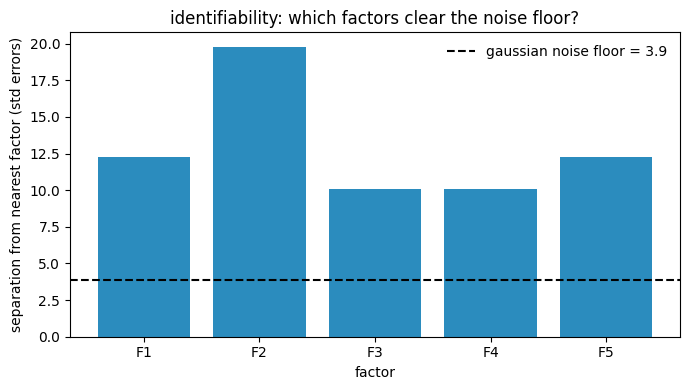

In [3]:
fm = FactorModel(n_factors=5, neutralize="auto").fit(size_bm)
tr = fm.trust_report()
print("auto-neutralized:", fm.neutralized_)
print(tr)

fig, ax = plt.subplots(figsize=(7, 4))
plot_margin(tr, ax=ax)
plt.tight_layout(); plt.show()

Every factor now clears the noise floor. That floor is not an arbitrary constant. The
identifiability margin — the minimum pairwise Euclidean distance between rows of the factors'
autocorrelation *signature* matrix, scaled by $\sqrt{T}$ — measures the separation of the two most
similar factors in standard-error units, but it has no absolute scale of its own. It is therefore
calibrated by simulation: the same pipeline — the same rotation, the same lags — is run 200 times on
data with no factor structure, and the threshold is set at the 95th percentile of the resulting
margin distribution. (The simulation uses a capped sample length rather than the full panel; the
$\sqrt{T}$ scaling in the margin is what makes the simulated and observed values comparable.) A factor
below that line is one whose estimated dynamics are statistically indistinguishable from what the
same rotation would produce on pure noise.

## 2. Blind rotation recovers distinct dynamics, not economic axes

With the rotation certified as identified, the natural next step is to regress each recovered
factor on the known Fama–French factors and read off the names. The result is instructive.

In [4]:
lab = fm.label(reference=ff)
print(lab)
lab.table.round(2)

LabelResult
  F1     ~ +0.19*HML +0.18*Mkt-RF       (R2=0.12)
  F2     ~ -0.55*HML +0.41*SMB          (R2=0.65)
  F3     ~ +0.59*HML +0.40*SMB          (R2=0.62)
  F4     ~ -0.70*SMB +0.20*HML          (R2=0.45)
  F5     ~ -0.39*Mkt-RF +0.35*HML       (R2=0.48)


,Mkt-RF,SMB,HML,RMW,CMA,Mom
F1,0.18,-0.17,0.19,-0.16,-0.14,-0.05
F2,-0.06,0.41,-0.55,-0.29,-0.10,0.03
F3,0.27,0.40,0.59,-0.08,-0.08,-0.08
F4,-0.07,-0.70,0.20,-0.10,-0.10,-0.03
F5,-0.39,0.17,0.35,0.02,0.12,0.06


The estimated factors come back as **mixtures**. Several are simultaneous combinations of `SMB` and
`HML` — in particular, two factors that are both size-value blends with opposite `HML` sign — and
the largest factor is often barely explained by the references at all. No row of this table (each
row is one estimated factor) supports the statement "this factor *is* value".

The explanation is an objective mismatch, and it is worth stating precisely. SOBI's objective is
*find the rotation whose sources have maximally distinct autocorrelation signatures*. The objective
we actually want is *find the rotation aligned with economically interpretable axes*. These are
different objectives, and no theorem connects them. SOBI's identification result holds under the
**assumption** that the true economic factors have distinguishable temporal dynamics — and on this
data, that assumption holds only partially. What the estimator delivers is exactly what it promised:
a correctly estimated **subspace**, rotated to separate *dynamics*. The **axes within that subspace**
are not thereby aligned with economic meaning.

This is a limitation of blind separation as applied to returns, not an implementation defect, and it
motivates the next step.

## 3. Target rotation: an interpretable basis at no cost in fit

If named axes are the objective, the appropriate instrument is not blind rotation but **target
rotation**. Given reference series $R$, the orthogonal Procrustes problem

$$Q^* = \arg\min_{Q^\top Q = I} \; \lVert S Q - R \rVert_F$$

admits a closed-form solution (Schönemann, 1966). `factorscope` computes it as the orthogonal
matrix nearest — in the polar-decomposition sense — to the unconstrained least-squares map
$A = \arg\min_A \lVert S A - R \rVert$: taking the singular value decomposition
$A = U \Sigma V^\top$, the rotation is $Q = U V^\top$. Intuitively, one *wants* the direction of the
unconstrained regression of the references on the factors, but one can only *afford* an orthogonal
rotation, and $U V^\top$ is the orthogonal matrix nearest to that regression. (Because the estimated
factors are standardized and mutually uncorrelated, $S^\top S \approx (T-1) I$, so this agrees with
the classical form of the Procrustes solution based on the SVD of $S^\top R$.)

The orthogonality constraint is what makes this legitimate rather than a refit. Since
$(SQ)(BQ)^\top = S Q Q^\top B^\top = S B^\top$, the reconstruction is preserved *exactly*: same
subspace, same fit, same variance forecast — only a more readable set of axes. `rotate_to()`
implements this.

TargetRotationResult (Procrustes rotation onto reference factors)
  SMB      |corr| with reference = 0.90
  HML      |corr| with reference = 0.79
  RMW      |corr| with reference = 0.42
  CMA      |corr| with reference = 0.43
  Mom      |corr| with reference = 0.24


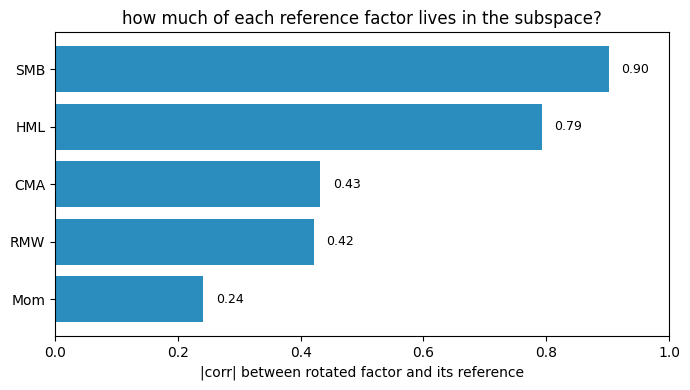

In [5]:
rot = fm.rotate_to(ff[STYLE])
print(rot)

fig, ax = plt.subplots(figsize=(7, 4))
plot_target_corr(rot, ax=ax)
plt.tight_layout(); plt.show()

The axes now have names, and the pattern of correlations is economically coherent. **Size and value
are strongly present**, while `RMW`, `CMA`, and momentum are considerably weaker — which is what
one should expect *a priori*, since these test portfolios are constructed by sorting on size and
book-to-market and on nothing else. A method that had also reported strong momentum here would be
cause for suspicion, not celebration.

The claim that the rotation left the fitted model untouched is checkable directly, so we check it.

In [6]:
S0 = ((fm.factors_ - fm.factors_.mean()) / fm.factors_.std()).values
Q = rot.rotation

before = S0 @ fm.loadings_.values.T
after = rot.factors.values @ rot.loadings.values.T

print(f"Q orthogonal      : max|QtQ - I| = {np.abs(Q.T @ Q - np.eye(len(Q))).max():.2e}")
print(f"subspace preserved: max|S_rot B_rot^T - S B^T| = {np.abs(after - before).max():.2e}")

Q orthogonal      : max|QtQ - I| = 8.60e-16
subspace preserved: max|S_rot B_rot^T - S B^T| = 7.72e-11


Both quantities are zero to machine precision. The target rotation is a **change of basis, not a
change of model**: nothing has been refit, and the reconstruction $S B^\top$ is numerically
identical before and after.

### Interpreting the correlation column

It is worth being precise about what `rotate_to()` does and does not establish. It performs
*interpretation by projection*, not blind discovery. The question it answers is: **what is the
closest object, inside the subspace I estimated, to the value factor?** The reported $|\text{corr}|$
is the answer to that question, and it is therefore diagnostic rather than decorative — a high value
indicates that the reference driver genuinely lives in the estimated subspace; a low value indicates
that it does not, and no rotation of any kind can conjure it into existence. The rotation chooses
the best available axis; it cannot create variance that the panel does not contain.

The result object reports a second, complementary quantity that makes this explicit: `subspace_r2`
is computed from the *unconstrained* least-squares fit, **before** any rotation is applied, and so
measures how much of each reference lives in the estimated subspace at all — independently of which
rotation is chosen. It is therefore the ceiling on what any rotation could achieve, while `corr`
measures the alignment actually attained under the orthogonality constraint.

Both are *results*, not tuning parameters. Section 4 makes this operational.

## 4. Negative control: a panel that does not contain the style factors

The result in §3 is a **positive control**. The 100 size/book-to-market portfolios are *constructed*
by sorting on size and book-to-market, so recovering size and value there validates the machinery
but discovers nothing about markets. A procedure that only ever confirms is not evidence of
anything.

The discriminating test is whether the same procedure declines to recover factors that are *not*
present. We therefore run the identical pipeline on **49 industry portfolios**, which are sorted on
industry membership and on no style characteristic. If the method is sound, the style factors should
be recovered *substantially more weakly* here.

     100 size/BM (positive control)  49 industry (negative control)
SMB                            0.90                            0.51
HML                            0.79                            0.46
RMW                            0.42                            0.35
CMA                            0.43                            0.39
Mom                            0.24                            0.21


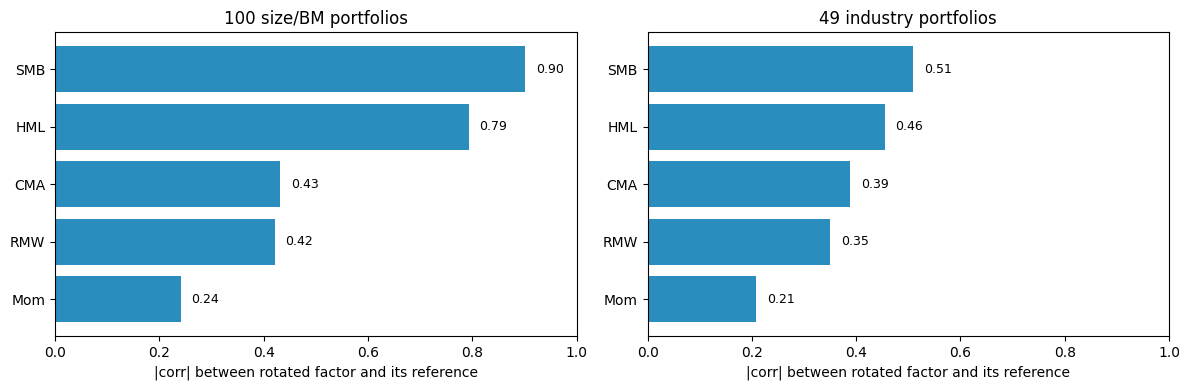

In [7]:
fm_ind = FactorModel(n_factors=5, neutralize="auto").fit(industry)
rot_ind = fm_ind.rotate_to(ff[STYLE])

comp = pd.DataFrame({
    "100 size/BM (positive control)": rot.corr,
    "49 industry (negative control)": rot_ind.corr,
}).round(2)
print(comp.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
plot_target_corr(rot, ax=axes[0]);     axes[0].set_title("100 size/BM portfolios")
plot_target_corr(rot_ind, ax=axes[1]); axes[1].set_title("49 industry portfolios")
plt.tight_layout(); plt.show()

The prediction holds. Size and value are markedly weaker in the industry panel: industry returns are
driven by sector dynamics, not by book-to-market sorts, and the procedure **reports that absence**
rather than manufacturing an alignment to satisfy the request. Because the same code path, on the
same reference factors, produced a strong result in §3 and a weak one here, the §3 result can be
read as informative about the data rather than as an artifact of the method.

## 5. Does factor identity survive a refit?

A risk model is refit periodically, and rotational indeterminacy has a second consequence in that
setting. Where eigenvalues are close, the sample eigenvectors are poorly determined and can
interchange between windows — so "Factor 3" may silently denote a different linear combination each
month, even when the subspace is perfectly stable. Because SOBI's rotation is pinned by temporal
structure rather than by variance ordering, its factors should exhibit greater persistence.

We test this by refitting on rolling windows and scoring each fit's loadings against the previous
window's, using a permutation- and sign-invariant matched correlation. Loadings rather than scores
are compared, since consecutive windows overlap in time and comparing scores would be partly
self-comparison.

StabilityResult
  refits            : 52  (window=1000, step=250)
  SOBI persistence  : 0.867
  PCA  persistence  : 0.834


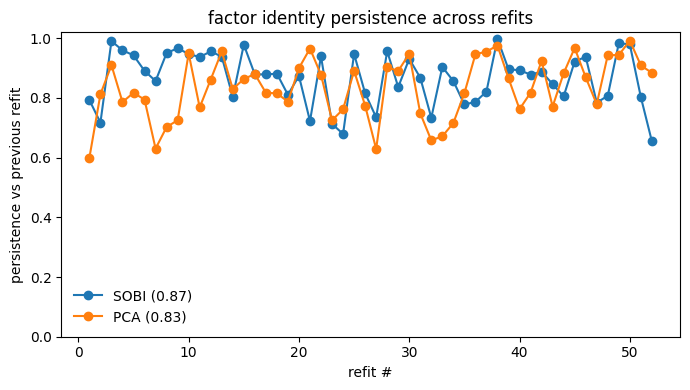

In [8]:
st = fm.stability_report(window=1000, step=250)
print(st)

fig, ax = plt.subplots(figsize=(7, 4))
plot_stability(st, ax=ax)
plt.tight_layout(); plt.show()

## Summary

| Question | Finding |
|---|---|
| Can an unidentified rotation be detected before it is interpreted? | **Yes.** The market-dominated panel is classified as such and its labels are not certified. |
| Does blind rotation (SOBI) deliver named economic factors? | **No.** It returns size/value blends. The objective it optimizes — distinct dynamics — is not the objective we want. |
| Can an interpretable basis be obtained? | **Yes**, by target rotation, which is provably a change of basis rather than a change of model. |
| Are the recovered factors genuinely size and value? | **In the size/BM panel, yes** (absolute correlations of 0.90 and 0.79 with the references) — but that panel is a positive control, so the result validates the machinery, it does not constitute a discovery. |
| Does the method recover factors that are not present? | **No.** Size and value come back markedly weaker on the industry panel, which is not sorted on either characteristic. |

## Conclusion

The contribution of `factorscope` is not that it names factors automatically; §2 establishes that
blind rotation, applied to returns, does not do so. The contribution is that it makes the
identification status of a statistical factor model *measurable* rather than assumed. It classifies
which spectral regime the panel occupies, calibrates the identifiability of the rotation against a
simulated null instead of an arbitrary threshold, supplies an interpretable basis by target rotation
where one exists — at no cost to the fit — and reports when the structure being sought is simply not
present in the data.

That last property is the one that gives the others their force: a diagnostic that cannot return a
negative result is not a diagnostic.